# Benchmarking Classic ML for Type-II Diabetes Prediction
**Dataset:** NFHS-5 (Final.csv) | **Target:** `Diabetes` (0 = No, 1 = Yes)

| Step | What we do |
|------|-----------|
| 1 | Load data, compute BMI, select features |
| 2 | Train-test split & scaling |
| 3 | Train 5 models × 3 imbalance strategies |
| 4 | Compare metrics (Accuracy, Recall, F1, ROC-AUC, Log Loss) |
| 5 | ROC curves + SHAP feature importance |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm             import SVC
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import (accuracy_score, recall_score, roc_auc_score,
                                     log_loss, f1_score, precision_score, roc_curve)
from imblearn.over_sampling  import SMOTE
import shap

print("All imports successful ✓")

os.makedirs('outputs', exist_ok=True)

All imports successful ✓


## 1. Load & Prepare Data

In [2]:
# Load CSV
df = pd.read_csv('Final.csv')

# Compute BMI  (height is in metres, weight in kg)
df['BMI'] = df['Resp_weight'] / (df['Resp_height'] ** 2)

# Subsample to 30 000 rows — SVM is very slow on 136k
df = df.sample(n=30_000, random_state=42)

# ── Key predictors (from assignment requirements) ────────────────────────────
FEATURES = [
    'Res_Age',              # Age
    'BMI',                  # Body Mass Index
    'Edu_level',            # Education level
    'Wealth_Idx_Lb',        # Wealth index
    'Tobacco',              # Tobacco use
    'Alcohol',              # Alcohol use
    'Hypertension',         # Hypertension status
    'ResidenceType_Urban',  # Urban / rural
    'Smoke',                # Smoking
    'Anemia_level',         # Anaemia level
]

X = df[FEATURES]
y = df['Diabetes']

print("Shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nDiabetes prevalence: {y.mean()*100:.2f}%")

Shape: (30000, 10)

Class distribution:
Diabetes
0    29728
1      272
Name: count, dtype: int64

Diabetes prevalence: 0.91%


## 2. Train-Test Split & Scaling

In [3]:
# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardise features  (mean = 0, std = 1)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Train: 24000 rows  |  Test: 6000 rows


## 3. Define Models

In [4]:
MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'         : GaussianNB(),
}

## 4. Evaluation Helper

In [5]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Train a model and return a dict of 6 metrics."""
    model.fit(X_tr, y_tr)

    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score (y_te, pred)                   * 100, 2),
        'Recall'    : round(recall_score   (y_te, pred)                   * 100, 2),
        'Precision' : round(precision_score(y_te, pred, zero_division=0)  * 100, 2),
        'F1'        : round(f1_score       (y_te, pred)                   * 100, 2),
        'ROC-AUC'   : round(roc_auc_score  (y_te, proba)                  * 100, 2),
        'Log Loss'  : round(log_loss       (y_te, proba)                  * 100, 2),
    }

## 5. Experiment 1 — No Imbalance Handling

In [6]:
results_none = []

for name, model in MODELS.items():
    print(f"  Training {name} ...")
    results_none.append(evaluate(name, model, X_train_sc, y_train, X_test_sc, y_test))

df_none = pd.DataFrame(results_none)
df_none

  Training Logistic Regression ...
  Training Random Forest ...
  Training SVM (RBF) ...
  Training AdaBoost ...
  Training Naive Bayes ...


,Model,Accuracy,Recall,Precision,F1,ROC-AUC,Log Loss
0,Logistic Regression,99.10,0.00,0.00,0.00,69.43,4.84
1,Random Forest,99.08,0.00,0.00,0.00,61.86,20.93
2,SVM (RBF),99.10,0.00,0.00,0.00,39.62,5.15
3,AdaBoost,99.10,0.00,0.00,0.00,65.99,31.95
4,Naive Bayes,94.52,25.93,4.62,7.84,71.60,48.56


## 6. Experiment 2 — SMOTE Oversampling

In [ ]:
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_sc, y_train)
print(f"After SMOTE  →  Class 0: {(y_sm==0).sum()}  |  Class 1: {(y_sm==1).sum()}")
results_smote = []
for name, model in MODELS.items():
    print(f"  Training {name} ...")
    results_smote.append(evaluate(name, model, X_sm, y_sm, X_test_sc, y_test))
df_smote = pd.DataFrame(results_smote)
df_smote

After SMOTE  →  Class 0: 23782  |  Class 1: 23782
  Training Logistic Regression ...
  Training Random Forest ...
  Training SVM (RBF) ...
  Training AdaBoost ...
  Training Naive Bayes ...


,Model,Accuracy,Recall,Precision,F1,ROC-AUC,Log Loss
0,Logistic Regression,83.50,42.59,2.34,4.44,67.03,55.72
1,Random Forest,98.18,0.00,0.00,0.00,59.94,20.95
2,SVM (RBF),83.52,35.19,1.95,3.70,56.48,45.16
3,AdaBoost,94.98,20.37,4.09,6.81,62.56,63.05
4,Naive Bayes,94.52,33.33,5.79,9.86,64.17,81.31


## 7. Experiment 3 — Class Weight (Cost-Sensitive)
> `AdaBoost` and `Naive Bayes` don't support `class_weight` — they run with defaults.

In [ ]:
CW_MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, class_weight='balanced'),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'         : GaussianNB(),
}
results_cw = []

for name, model in CW_MODELS.items():
    print(f"  Training {name} ...")
    results_cw.append(evaluate(name, model, X_train_sc, y_train, X_test_sc, y_test))

df_cw = pd.DataFrame(results_cw)
df_cw

  Training Logistic Regression ...
  Training Random Forest ...
  Training SVM (RBF) ...
  Training AdaBoost ...
  Training Naive Bayes ...


,Model,Accuracy,Recall,Precision,F1,ROC-AUC,Log Loss
0,Logistic Regression,84.70,42.59,2.53,4.77,68.27,55.40
1,Random Forest,99.08,0.00,0.00,0.00,64.12,19.78
2,SVM (RBF),84.47,42.59,2.49,4.70,63.16,4.98
3,AdaBoost,99.10,0.00,0.00,0.00,65.99,31.95
4,Naive Bayes,94.52,25.93,4.62,7.84,71.60,48.56


## 8. Full Results Comparison

In [ ]:
df_none['Method']  = 'No Handling'
df_smote['Method'] = 'SMOTE'
df_cw['Method']    = 'Class Weight'

summary = pd.concat([df_none, df_smote, df_cw], ignore_index=True)
summary = summary[['Method','Model','Accuracy','Recall','Precision','F1','ROC-AUC','Log Loss']]
summary.to_csv('outputs/model_results.csv', index=False)
summary.style.highlight_max(subset=['Recall','F1','ROC-AUC'], color='lightgreen')              .highlight_min(subset=['Log Loss'],               color='lightgreen')

,Method,Model,Accuracy,Recall,Precision,F1,ROC-AUC,Log Loss
0,No Handling,Logistic Regression,99.100000,0.000000,0.000000,0.000000,69.430000,4.840000
1,No Handling,Random Forest,99.080000,0.000000,0.000000,0.000000,61.860000,20.930000
2,No Handling,SVM (RBF),99.100000,0.000000,0.000000,0.000000,39.620000,5.150000
3,No Handling,AdaBoost,99.100000,0.000000,0.000000,0.000000,65.990000,31.950000
4,No Handling,Naive Bayes,94.520000,25.930000,4.620000,7.840000,71.600000,48.560000
5,SMOTE,Logistic Regression,83.500000,42.590000,2.340000,4.440000,67.030000,55.720000
6,SMOTE,Random Forest,98.180000,0.000000,0.000000,0.000000,59.940000,20.950000
7,SMOTE,SVM (RBF),83.520000,35.190000,1.950000,3.700000,56.480000,45.160000
8,SMOTE,AdaBoost,94.980000,20.370000,4.090000,6.810000,62.560000,63.050000
9,SMOTE,Naive Bayes,94.520000,33.330000,5.790000,9.860000,64.170000,81.310000


## 8b. Model Comparison Chart

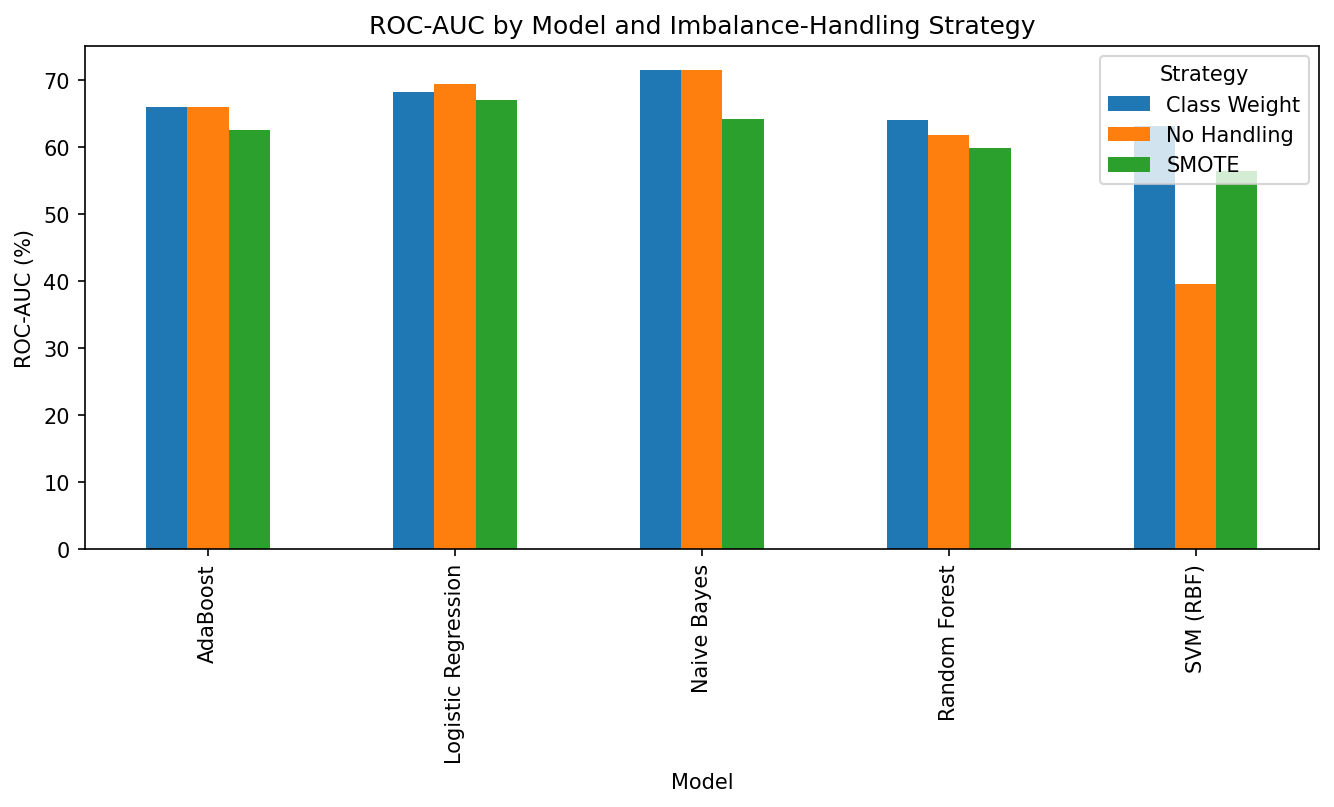

In [ ]:
pivot = summary.pivot_table(values='ROC-AUC', index='Model', columns='Method')
pivot.plot(kind='bar', figsize=(9, 5.5))
plt.ylabel('ROC-AUC (%)')
plt.title('ROC-AUC by Model and Imbalance-Handling Strategy')
plt.legend(title='Strategy')
plt.tight_layout()
plt.savefig('outputs/model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC Curves — SMOTE Models

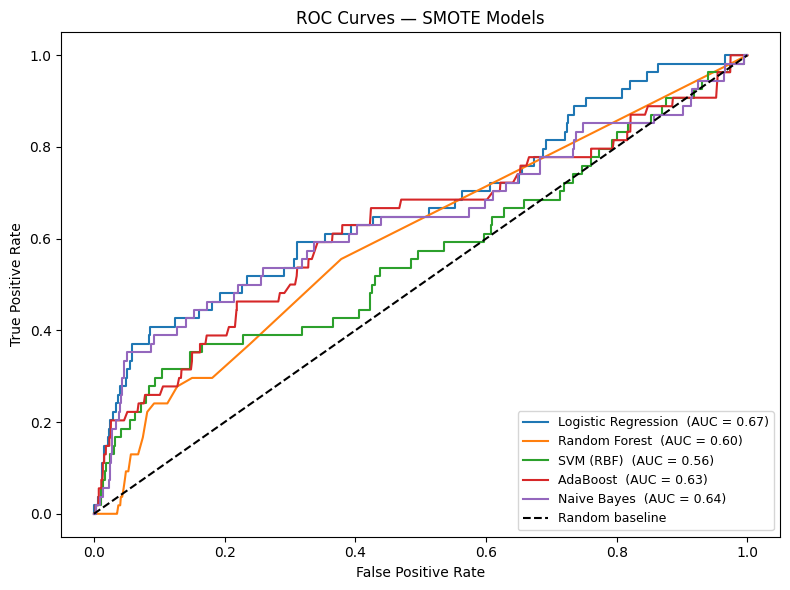

In [10]:
plt.figure(figsize=(8, 6))

for name, model in MODELS.items():
    model.fit(X_sm, y_sm)
    proba       = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc         = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — SMOTE Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. SHAP Feature Importance — Random Forest + SMOTE

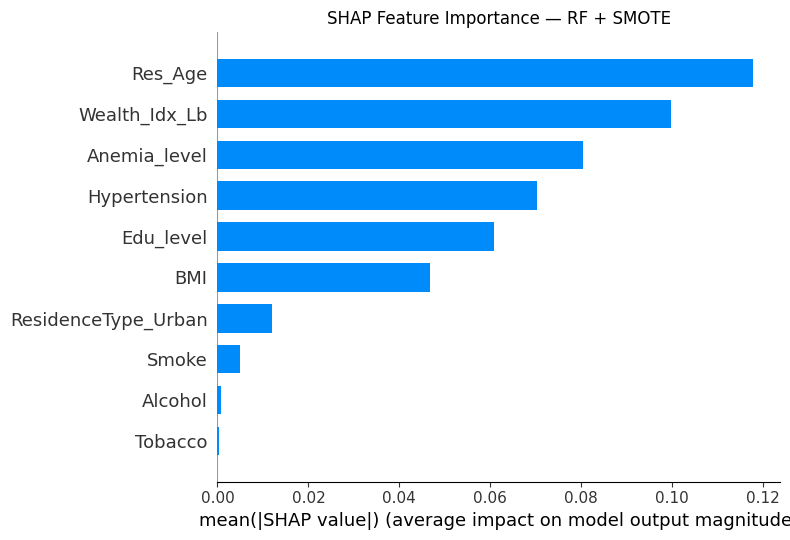

In [11]:
# Train RF on SMOTE data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_sm, y_sm)

# Use 300 test samples for speed
X_sample  = pd.DataFrame(X_test_sc[:300], columns=FEATURES)
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_sample)

# Handle both old API (list) and new API (3-D array)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals[:, :, 1]

shap.summary_plot(sv, X_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — RF + SMOTE')
plt.tight_layout()
plt.savefig('outputs/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Logistic Regression — Odds Ratios

In [12]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_sc, y_train)

odds = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lr.coef_[0],
    'Odds Ratio' : np.exp(lr.coef_[0]),
}).sort_values('Odds Ratio', ascending=False)

print(odds.to_string(index=False))
odds.to_csv('outputs/odds_ratios.csv', index=False)

            Feature  Coefficient  Odds Ratio
       Hypertension     0.513751    1.671550
            Res_Age     0.298693    1.348095
                BMI     0.182053    1.199678
            Alcohol     0.060579    1.062451
      Wealth_Idx_Lb     0.052008    1.053384
          Edu_level     0.018512    1.018684
            Tobacco     0.007706    1.007735
              Smoke    -0.019027    0.981153
ResidenceType_Urban    -0.035376    0.965243
       Anemia_level    -0.155736    0.855785
